<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-10/dimensionality_reduction_pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 10 — Dimensionality reduction with PCA

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
1. Understand why we reduce dimensions: **visualization, denoising, compression**.
2. Apply **Principal Component Analysis (PCA)** with `scikit-learn`.
3. Read the **explained-variance** curve to choose the number of components.
4. Interpret **component loadings** and project data into 2-D.

This lecture is *unsupervised* — no labels. We analyze the structure of the
Maceió weather features ([dataset card](../../datasets/maceio_daily_weather.DATASET.md))
and connect back to clustering (lecture 09).

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

wx = load_dataset("maceio_daily_weather.csv")
features = ["temp_max_c", "temp_min_c", "temp_mean_c", "humidity_pct",
            "pressure_hpa", "wind_max_kmh", "solar_rad_mj_m2", "precip_mm"]
X = StandardScaler().fit_transform(wx[features].values)
print("standardized matrix:", X.shape)

standardized matrix: (5479, 8)


## 1. How many dimensions do we really need?

PCA finds orthogonal directions ("components") ordered by how much **variance**
they capture. The cumulative curve tells us how many we need to keep most of the
information.

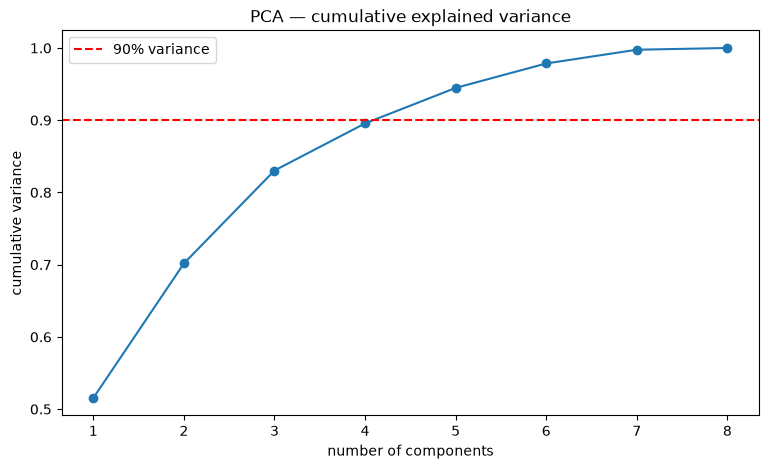

5 components explain >= 90% of the variance (out of 8)


In [3]:
pca = PCA().fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1, len(cum) + 1), cum, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% variance")
plt.title("PCA — cumulative explained variance")
plt.xlabel("number of components"); plt.ylabel("cumulative variance"); plt.legend(); plt.show()
k90 = int(np.argmax(cum >= 0.9) + 1)
print(f"{k90} components explain >= 90% of the variance (out of {len(features)})")

## 2. What do the first two components mean?

Each component is a weighted mix of the original features (its **loadings**).
Reading them turns abstract axes into physical meaning.

In [4]:
import pandas as pd
loadings = pd.DataFrame(pca.components_[:2].T, index=features, columns=["PC1", "PC2"]).round(2)
print(loadings)

                  PC1   PC2
temp_max_c       0.47  0.10
temp_min_c       0.40  0.31
temp_mean_c      0.47  0.21
humidity_pct    -0.25  0.56
pressure_hpa    -0.37 -0.36
wind_max_kmh     0.10 -0.24
solar_rad_mj_m2  0.39 -0.31
precip_mm       -0.23  0.51


## 3. Project the data into 2-D

We keep the first two components and plot every day. Coloring by **month** shows
whether PCA recovered the seasonal cycle without ever being told about it.

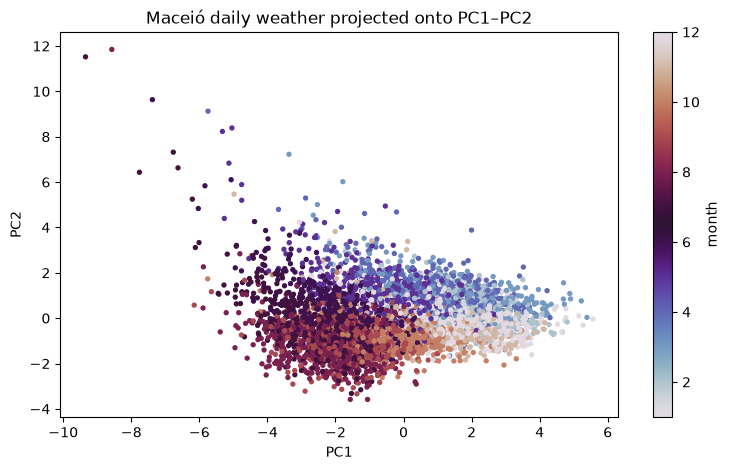

In [5]:
Z = PCA(n_components=2).fit_transform(X)
sc = plt.scatter(Z[:, 0], Z[:, 1], c=wx["month"], cmap="twilight", s=8)
plt.colorbar(sc, label="month")
plt.title("Maceió daily weather projected onto PC1–PC2")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()

## 4. Clustering in the reduced space

Combining lectures 09 and 10: run **K-Means** on the 2-D projection to discover
"weather regimes" — data-driven day types.

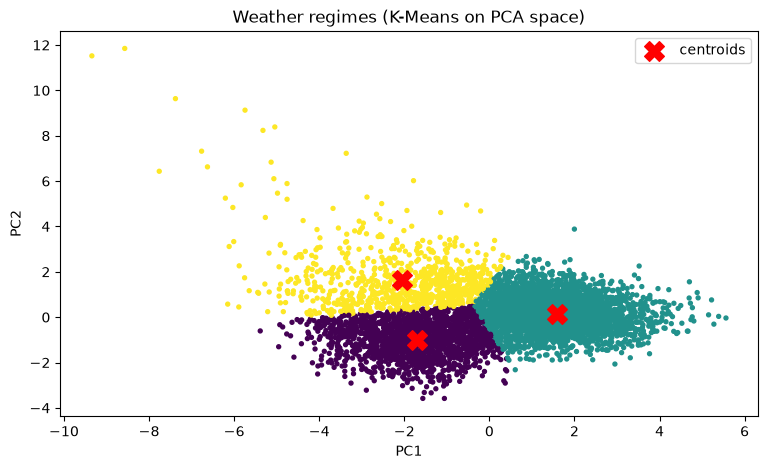

         temp_mean_c  humidity_pct  precip_mm
cluster                                      
0               24.6          77.8        2.6
1               26.7          76.9        1.6
2               25.0          86.2       10.8


In [6]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Z)
sc = plt.scatter(Z[:, 0], Z[:, 1], c=km.labels_, cmap="viridis", s=8)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, label="centroids")
plt.title("Weather regimes (K-Means on PCA space)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.show()

wx2 = wx.copy(); wx2["cluster"] = km.labels_
print(wx2.groupby("cluster")[["temp_mean_c", "humidity_pct", "precip_mm"]].mean().round(1))

## What did we learn?
- PCA compresses correlated features into a few components; here a handful explain
  most of the variance because temperature variables move together.
- **Loadings** make the components interpretable (e.g. a "hot & sunny vs. humid &
  rainy" axis).
- Reducing to 2-D enables **visualization** and feeds nicely into **clustering**,
  revealing natural day-types in the climate record.

### Exercises
1. Re-run PCA **without** standardizing the features. Why does `pressure_hpa`
   suddenly dominate? What does this teach about scaling?
2. Use the `k90` components as input to the lecture-05 rain classifier instead of
   the raw features. Does compression hurt or help accuracy?
3. Color the 2-D projection by `rained` instead of month. Are rainy days
   separable in PCA space?
4. **Discuss:** PCA finds directions of maximum *variance*. Give a scenario where
   the most informative direction for a task is **not** the highest-variance one.